## Thermal Model Tutorial
Author : Henry Nachman

Date : 25 July 2025

This notebook will walk you through how to use the thermal model as a python package.

### Creating a Thermal Model

If you haven't yet created a thermal model, the streamlit gui can be used to easily create a model in the right format.

In [ ]:
# First let's import the necessary libraries
from thermal_model.gui_init import init_gui

# now let's run the streamlit app
init_gui()

Starting the Streamlit GUI...


_Note : if this is your first time running the thermal model, you will need to specify the path to the local clone of the Cryogenic Materials Repository Github repository. The streamlit app will prompt you to do this if it is not already set._

The Streamlit GUI incorporates several tools that may be desired, such as an optimization button.

### Thermal Model tools

Now that we have a json file in the appropriate format, manipulation of the thermal model can be done entirely in Python.

In [ ]:
import json, os
from thermal_model.stage_calc import load_thermal_model
# Specify the path to the JSON file containing the thermal model
json_path = "model.json"
tm = load_thermal_model(json_path)

In [2]:
from thermal_model_class import ThermalModel as TM

# Now we can create a ThermalModel object from the loaded JSON data
blast_tm = TM(tm)
print(blast_tm.components)

# The ThermalModel object has various methods to manipulate and inspect thermal model.
comp = blast_tm.get_component("Coax In 1K", "300mK_MC")
print(comp.name, comp.total_power)


{'1K_MC': {'Coax In': {'Type': 'A/L', 'Material': 'CuNi_Coax', 'Interpolate': True, 'Fit Choice': None, 'A/L (m)': 10.0, 'Number': 8, 'Providing Vapor': False, 'Power per Part (W)': 9.898624994519796e-08, 'Power Total (W)': 7.918899995615837e-07}, 'Coax Out': {'Type': 'A/L', 'Material': 'NbTi160_Coax', 'Interpolate': True, 'Fit Choice': None, 'A/L (m)': 10.0, 'Number': 8, 'Providing Vapor': False}}, '300mK_MC': {'Coax In': {'Type': 'A/L', 'Material': 'CuNi_Coax', 'Interpolate': True, 'Fit Choice': None, 'A/L (m)': 10.0, 'Number': 8, 'Providing Vapor': False, 'Power per Part (W)': 3.655082791823959e-20, 'Power Total (W)': 2.9240662334591673e-19}, 'Coax Out': {'Type': 'A/L', 'Material': 'NbTi160_Coax', 'Interpolate': True, 'Fit Choice': None, 'A/L (m)': 10.0, 'Number': 8, 'Providing Vapor': False, 'Power per Part (W)': 4.195356855940857e-09, 'Power Total (W)': 3.3562854847526854e-08}, 'Coax In 1K': {'Type': 'A/L', 'Material': 'CuNi_Coax', 'Interpolate': True, 'Fit Choice': None, 'A/L (m)

In [4]:
print(comp.properties)

{'Type': 'A/L', 'Material': 'CuNi_Coax', 'Interpolate': True, 'Fit Choice': None, 'A/L (m)': 10.0, 'Number': 8, 'Providing Vapor': False, 'Warm Stage Temp (K)': 1.1, 'Power per Part (W)': 3.655082791823959e-20, 'Power Total (W)': 2.9240662334591673e-19}


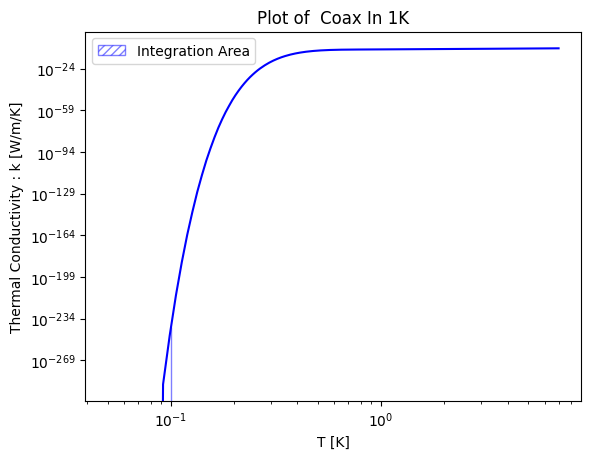

In [3]:
comp.plot()

In [4]:
blast_tm.plot_stage("VCS 1", streamlit=False)

In [5]:
help(blast_tm.plot_stage)

Help on method plot_stage in module thermal_model_class:

plot_stage(stage_name, streamlit=False) method of thermal_model_class.ThermalModel instance
    Plot the thermal model for a specific stage.

    Args:
        stage_name (str): The name of the stage to plot.
        streamlit (bool, optional): Whether to use Streamlit for plotting. Defaults to False.

    Returns:
        Figure: The plotted figure.



[ True  True  True  True  True  True  True  True  True  True  True]
[ True  True False  True False  True  True  True  True  True  True]


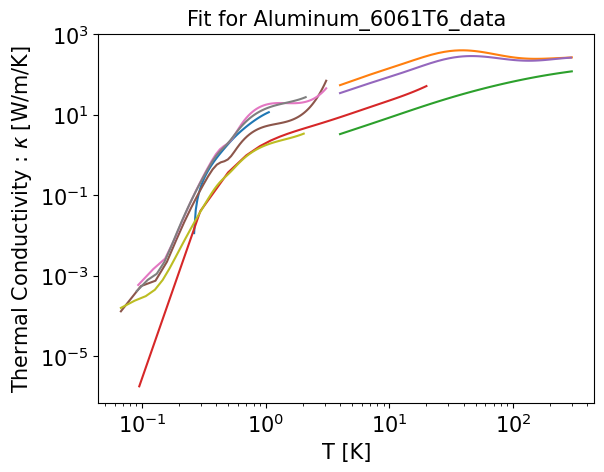

In [22]:
from thermal_conductivity.tc_utils import *

from material_class import Material, Fit, DataSet
material_of_interest = "Aluminum"
al_mat = get_material(material_of_interest)

fit_boolean = np.ones(len(al_mat.fits), dtype=bool)
print(fit_boolean)
fit_boolean[4] = False
fit_boolean[2] = False

print(fit_boolean)


result = [d for d, m in zip(al_mat.fits,fit_boolean) if m]
# print([fit for fit in al_mat.fits])
for fit in result:
    fit.plot()